In [2]:
from langgraph.graph import StateGraph, START, END
try:
    from typing import TypedDict
except ImportError:
    from typing_extensions import TypedDict

In [18]:
# define state of object for that we can inherite typdic from typing 

class BmiState(TypedDict) : 
    weight_kg : float
    height_m : float
    bmi :float
    Health_category : str

# define graph : for define graph we have to provide state into graph and create graph from StateGraph - to register graph
graph = StateGraph(BmiState)

# creating node function - to clculate bmi
def calculate_bmi(state: BmiState) -> BmiState:
    weight = state['weight_kg']
    height = state['height_m']
    # calculating bmi with formula
    bmi = weight / (height ** 2)
    # add this bmi into state object partially
    state['bmi'] = round(bmi, 2)
    return state
# creating function which describe the health - based on calculated bmi
def calculate_health_chech(state :BmiState ) -> BmiState:
 #get bmi from -> state object
 bmi = state['bmi']
 print(bmi)
 if bmi < 18.5:
    state['Health_category'] = 'underweight'
 elif 18.5 <=bmi <25:
    state['Health_category'] = 'Normal'
 elif 25 <=bmi <30:
    state['Health_category'] = 'overweight'
 elif bmi>30 :
    state['Health_category'] = 'Obese'
 return state
 
# define nodes and respective functions of it
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('calculate_health_chech',calculate_health_chech)
# add edges - which describe from which node to call which - flow execution - for that we need to declare two dummy edges start, end
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi','calculate_health_chech')
graph.add_edge('calculate_health_chech',END)

# compile graph - to check graph is working well or not 
graph_workflow = graph.compile()
# excute the graph - we have to provice initial - state , and after execution graph will return state as result 
inital_state = ({'weight_kg' : 100, 'height_m': 1.73})

final_state = graph_workflow.invoke(inital_state)
print(final_state)




33.41
{'weight_kg': 100, 'height_m': 1.73, 'bmi': 33.41, 'Health_category': 'Obese'}


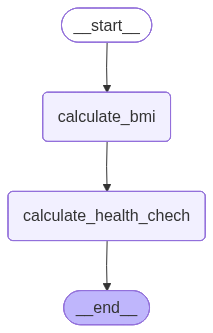

In [13]:
from IPython.display import Image
Image(graph_workflow.get_graph().draw_mermaid_png())